# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

Label encoder asigna un numero a la variable, pero podria causar problemas como en este caso que asigna un valor mas alto a los
hombres, siendo algo sexista, y one hot encoder añade una nueva columna validando si es true o false la existencia de la variable
pero amplia de mas la muestra al generar tantas columnas nuevas

In [8]:
# Muestra cómo transformó LabelEncoder la variable 'sex'
print("--- EFECTO DE LABELENCODER ---")
print(data[['sex', 'sex_label']].drop_duplicates().to_string(index=False))

# Muestra cómo transformó OneHotEncoder la variable 'embarked'
print("\n--- EFECTO DE ONEHOTENCODER ---")
print(data[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].dropna().drop_duplicates().to_string(index=False))

--- EFECTO DE LABELENCODER ---
   sex  sex_label
  male          1
female          0

--- EFECTO DE ONEHOTENCODER ---
embarked  embarked_C  embarked_Q  embarked_S
       S       False       False        True
       C        True       False       False
       Q       False        True       False


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

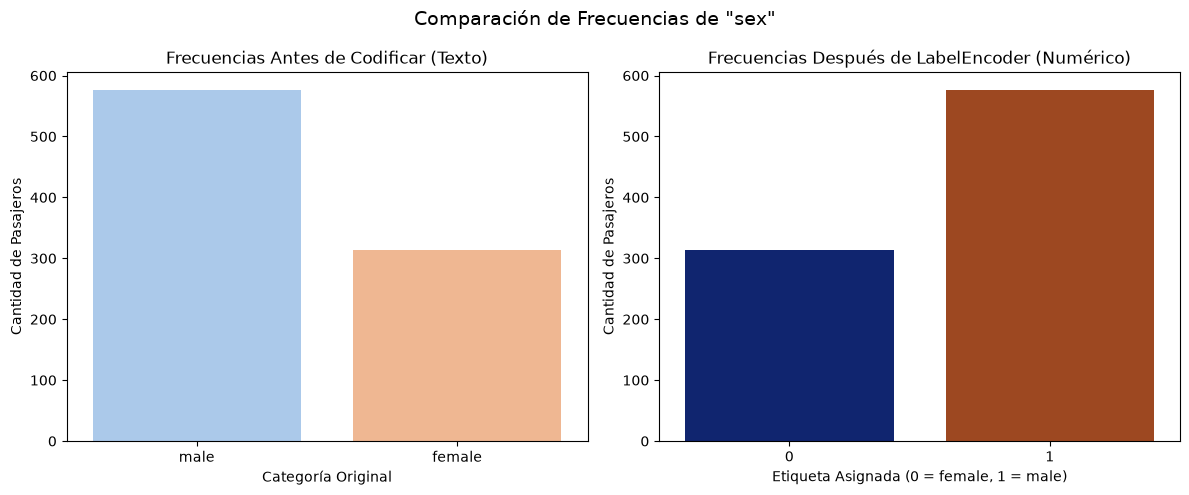

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura la ventana para dos gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafica los datos originales (Texto)
sns.countplot(x='sex', data=data, ax=axes[0], palette='pastel', hue='sex', legend=False)
axes[0].set_title('Frecuencias Antes de Codificar (Texto)')
axes[0].set_xlabel('Categoría Original')
axes[0].set_ylabel('Cantidad de Pasajeros')

# Grafica los datos ya codificados (Numérico)
sns.countplot(x='sex_label', data=data, ax=axes[1], palette='dark', hue='sex_label', legend=False)
axes[1].set_title('Frecuencias Después de LabelEncoder (Numérico)')
axes[1].set_xlabel('Etiqueta Asignada (0 = female, 1 = male)')
axes[1].set_ylabel('Cantidad de Pasajeros')

plt.suptitle('Comparación de Frecuencias de "sex"', fontsize=14)
plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

a que el modelo no asumira que existe una relacion de venteja entre el valor de una variable a otra, por ejemplo asumir que los
hombres sean mejores que las mujeres

In [10]:
# Codifica la columna 'class' usando pd.get_dummies
onehot_class = pd.get_dummies(data['class'], prefix='class')

# Muestra las primeras filas del resultado en pantalla
print("Estructura de la columna 'class' con OneHotEncoder:")
print(onehot_class.head())

# Combina estas nuevas columnas con nuestro dataframe original por buenas practicas
data = pd.concat([data, onehot_class], axis=1)

Estructura de la columna 'class' con OneHotEncoder:
   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

Depende de la variable, por ejemplo para cosas subjetivas como el genero o sexo seria un error usar label encoder ya que se asigna 
mas valor a una persona unicamente por su sexo o genero, en cambio en variables objetivas como la clase, donde si es mejor primera
clase que segunda clase, ahi si podria usarse label encoder.